# Feature Engineering for Machine Learning

This notebook introduces practical feature engineering for tabular machine learning.

Dataset: a synthetic customer churn dataset generated inside the notebook. It includes numeric columns, categorical columns, dates, free-text support notes, missing values, and a binary target. The synthetic setup keeps the notebook fully offline while still looking like a real mixed-type business dataset.

We will cover:

- why feature engineering should be done inside train-only pipelines;
- numeric transformations for skewed and missing data;
- categorical encoding with safe handling of unseen categories;
- date-derived features such as tenure and recency;
- simple interaction features;
- text features with TF-IDF;
- a complete `ColumnTransformer` + `Pipeline` workflow;
- how to inspect the engineered feature names and model coefficients.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
REFERENCE_DATE = pd.Timestamp("2026-01-01")

pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 4)

plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "figure.figsize": (9, 5),
})


## 1. Create a Mixed-Type Teaching Dataset

Most real tabular ML problems are not clean numeric matrices. They often contain dates, categories, skewed amounts, counts, free text, and missing values.

The function below creates a churn-like dataset with those ingredients. The target is intentionally influenced by recency, engagement, contract type, price, support activity, and support-note language, so feature engineering has useful signal to recover.


In [2]:
def sigmoid(values):
    return 1 / (1 + np.exp(-values))


def make_customer_churn_data(n_rows=3_000, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)

    plan = rng.choice(
        ["basic", "plus", "pro", "enterprise"],
        size=n_rows,
        p=[0.34, 0.32, 0.24, 0.10],
    )
    region = rng.choice(
        ["north", "south", "east", "west"],
        size=n_rows,
        p=[0.26, 0.24, 0.25, 0.25],
    )
    acquisition_channel = rng.choice(
        ["organic", "paid_search", "referral", "partner"],
        size=n_rows,
        p=[0.36, 0.28, 0.22, 0.14],
    )

    annual_probability = np.select(
        [plan == "enterprise", plan == "pro", plan == "plus"],
        [0.74, 0.50, 0.35],
        default=0.20,
    )
    contract = np.where(
        rng.random(n_rows) < annual_probability,
        "annual",
        "month_to_month",
    )

    age = np.clip(rng.normal(41, 13, n_rows).round(), 18, 80).astype(int)
    signup_age_days = rng.integers(20, 5 * 365, size=n_rows)
    signup_date = REFERENCE_DATE - pd.to_timedelta(signup_age_days, unit="D")

    base_logins = np.select(
        [plan == "enterprise", plan == "pro", plan == "plus"],
        [22, 16, 11],
        default=7,
    )
    num_logins_30d = rng.poisson(base_logins)

    support_tickets_90d = rng.poisson(
        0.7
        + 0.4 * (plan == "enterprise")
        + 0.5 * (contract == "month_to_month")
        + 0.3 * (num_logins_30d <= 3)
    )

    last_login_days_ago = np.clip(
        (
            rng.gamma(shape=2.2, scale=6.5, size=n_rows)
            + 4 * (plan == "basic")
            - 2 * (contract == "annual")
            + 3 * (support_tickets_90d >= 3)
        ).round(),
        0,
        120,
    ).astype(int)
    last_login = REFERENCE_DATE - pd.to_timedelta(last_login_days_ago, unit="D")

    plan_charge_lift = pd.Series(plan).map({
        "basic": 0,
        "plus": 18,
        "pro": 42,
        "enterprise": 78,
    }).to_numpy()
    monthly_charges = np.clip(
        rng.lognormal(mean=3.45, sigma=0.45, size=n_rows) + plan_charge_lift,
        20,
        260,
    )

    avg_session_minutes = np.clip(
        rng.normal(16 + 0.35 * num_logins_30d - 0.7 * support_tickets_90d, 6, n_rows),
        2,
        80,
    )

    note_risk_probability = sigmoid(
        -1.4
        + 0.45 * support_tickets_90d
        + 0.025 * last_login_days_ago
        + 0.35 * (contract == "month_to_month")
    )
    note_positive_probability = sigmoid(
        -0.2
        + 0.08 * num_logins_30d
        - 0.03 * last_login_days_ago
        - 0.45 * support_tickets_90d
    )

    random_for_risk = rng.random(n_rows)
    random_for_positive = rng.random(n_rows)
    note_bucket = np.where(
        random_for_risk < note_risk_probability,
        "risk",
        np.where(random_for_positive < note_positive_probability, "positive", "neutral"),
    )

    positive_notes = np.array([
        "praised onboarding and product fit",
        "asked about annual renewal",
        "reported feature working well",
        "shared positive support feedback",
    ])
    neutral_notes = np.array([
        "asked a billing question",
        "requested account details",
        "checked plan limits",
        "updated profile information",
    ])
    risk_notes = np.array([
        "asked about cancellation",
        "reported repeated billing issue",
        "complained about missing feature",
        "mentioned competitor pricing",
    ])

    latest_ticket_note = []
    for bucket in note_bucket:
        if bucket == "risk":
            latest_ticket_note.append(rng.choice(risk_notes))
        elif bucket == "positive":
            latest_ticket_note.append(rng.choice(positive_notes))
        else:
            latest_ticket_note.append(rng.choice(neutral_notes))

    note_effect = np.select(
        [note_bucket == "risk", note_bucket == "positive"],
        [0.90, -0.45],
        default=0.0,
    )
    churn_logit = (
        -1.15
        + 0.036 * last_login_days_ago
        - 0.075 * num_logins_30d
        + 0.018 * (monthly_charges - 75)
        + 0.38 * (support_tickets_90d >= 3)
        + 0.58 * (contract == "month_to_month")
        - 0.32 * (contract == "annual")
        + 0.44 * ((plan == "basic") & (monthly_charges > 70))
        + 0.25 * (region == "south")
        + note_effect
        + rng.normal(0, 0.45, n_rows)
    )
    churn = rng.binomial(1, sigmoid(churn_logit))

    X = pd.DataFrame({
        "age": age,
        "monthly_charges": monthly_charges.round(2),
        "num_logins_30d": num_logins_30d,
        "support_tickets_90d": support_tickets_90d,
        "avg_session_minutes": avg_session_minutes.round(1),
        "plan": plan,
        "contract": contract,
        "region": region,
        "acquisition_channel": acquisition_channel,
        "signup_date": signup_date,
        "last_login": last_login,
        "latest_ticket_note": latest_ticket_note,
    })

    missing_rates = {
        "monthly_charges": 0.07,
        "avg_session_minutes": 0.06,
        "region": 0.03,
        "acquisition_channel": 0.02,
    }
    for column, rate in missing_rates.items():
        missing_mask = rng.random(n_rows) < rate
        X.loc[missing_mask, column] = np.nan

    return X, pd.Series(churn, name="churn")


X, y = make_customer_churn_data()
data = X.assign(churn=y)

display(data.head())
display(pd.DataFrame({
    "rows": [len(data)],
    "features": [X.shape[1]],
    "churn_rate": [y.mean()],
}))


,age,monthly_charges,num_logins_30d,support_tickets_90d,avg_session_minutes,plan,contract,region,acquisition_channel,signup_date,last_login,latest_ticket_note,churn
0,45,75.16,32,1,20.9,pro,month_to_month,west,paid_search,2021-02-15,2025-11-29,asked about cancellation,0
1,25,NaN,14,2,18.0,plus,annual,east,organic,2024-05-05,2025-12-23,asked about cancellation,0
2,36,81.09,13,0,NaN,pro,annual,north,paid_search,2024-01-19,2025-12-23,praised onboarding and product fit,1
3,33,93.26,16,0,15.1,pro,annual,east,organic,2022-03-11,2025-12-16,praised onboarding and product fit,1
4,28,20.00,6,2,11.8,basic,annual,north,organic,2022-10-25,2025-12-26,updated profile information,0


,rows,features,churn_rate
0,3000,12,0.281


In [3]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   age                  3000 non-null   int64         
 1   monthly_charges      2806 non-null   float64       
 2   num_logins_30d       3000 non-null   int64         
 3   support_tickets_90d  3000 non-null   int64         
 4   avg_session_minutes  2822 non-null   float64       
 5   plan                 3000 non-null   object        
 6   contract             3000 non-null   object        
 7   region               2905 non-null   object        
 8   acquisition_channel  2939 non-null   object        
 9   signup_date          3000 non-null   datetime64[ns]
 10  last_login           3000 non-null   datetime64[ns]
 11  latest_ticket_note   3000 non-null   object        
 12  churn                3000 non-null   int64         
dtypes: datetime64[ns](2), float64(2),

## 2. Split Before Engineering

Feature engineering can leak information when statistics are learned from the full dataset before the split. Examples include imputing with a global median, scaling with a global mean, selecting features using the full target, or encoding rare categories using test-set frequencies.

The safe default is:

1. split into train and test;
2. fit preprocessing only on training data;
3. apply the learned preprocessing to validation/test data through a `Pipeline`.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Train rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")
print(f"Train churn rate: {y_train.mean():.3f}")
print(f"Test churn rate: {y_test.mean():.3f}")


Train rows: 2,250
Test rows: 750
Train churn rate: 0.281
Test churn rate: 0.281


In [5]:
def evaluate_classifier(model_name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    y_score = model.predict_proba(X_eval)[:, 1]

    return {
        "model": model_name,
        "accuracy": accuracy_score(y_eval, y_pred),
        "f1": f1_score(y_eval, y_pred),
        "roc_auc": roc_auc_score(y_eval, y_score),
    }


results = []


## 3. Numeric Baseline

Start with a deliberately narrow baseline: only numeric features, median imputation, scaling, and Logistic Regression.

This is not the final model. It gives us a reference point so every feature engineering step has something to beat.


In [6]:
numeric_features = [
    "age",
    "monthly_charges",
    "num_logins_30d",
    "support_tickets_90d",
    "avg_session_minutes",
]

numeric_baseline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegression(max_iter=2_000),
)

numeric_baseline.fit(X_train[numeric_features], y_train)
results.append(evaluate_classifier(
    "numeric baseline",
    numeric_baseline,
    X_test[numeric_features],
    y_test,
))

pd.DataFrame(results)


,model,accuracy,f1,roc_auc
0,numeric baseline,0.7253,0.1694,0.6356


## 4. Categorical Encoding

Most ML estimators need numbers, not labels such as `basic` or `annual`. One-hot encoding converts each category into a binary indicator.

`handle_unknown="ignore"` is important in production-style workflows: if a new category appears at prediction time, the transformer will not fail.


In [7]:
encoder_demo = OneHotEncoder(handle_unknown="ignore")
encoder_demo.fit(pd.DataFrame({"plan": ["basic", "plus", "pro"]}))

pd.DataFrame(
    encoder_demo.transform(pd.DataFrame({"plan": ["basic", "student"]})).toarray(),
    columns=encoder_demo.get_feature_names_out(),
    index=["known category", "new category"],
)


,plan_basic,plan_plus,plan_pro
known category,1.0,0.0,0.0
new category,0.0,0.0,0.0


In [8]:
categorical_features = ["plan", "contract", "region", "acquisition_channel"]

raw_tabular_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            make_pipeline(SimpleImputer(strategy="median"), StandardScaler()),
            numeric_features,
        ),
        (
            "categorical",
            make_pipeline(
                SimpleImputer(strategy="most_frequent"),
                OneHotEncoder(handle_unknown="ignore"),
            ),
            categorical_features,
        ),
    ]
)

raw_tabular_model = make_pipeline(
    raw_tabular_preprocessor,
    LogisticRegression(max_iter=2_000, class_weight="balanced"),
)

raw_tabular_model.fit(X_train, y_train)
results.append(evaluate_classifier("numeric + categorical", raw_tabular_model, X_test, y_test))

pd.DataFrame(results).sort_values("roc_auc", ascending=False)


,model,accuracy,f1,roc_auc
1,numeric + categorical,0.6093,0.4758,0.6607
0,numeric baseline,0.7253,0.1694,0.6356


## 5. Numeric Transformations

Linear models are sensitive to the shape and scale of numeric inputs. A skewed amount such as `monthly_charges` can be easier for a model after a log transform.

The transformation must be inside the pipeline, after imputation and before scaling.


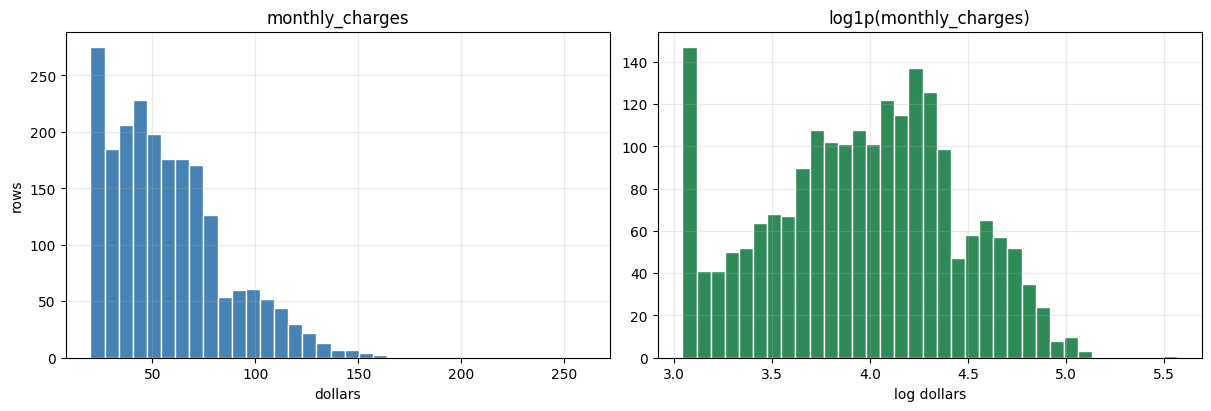

In [9]:
charges = X_train["monthly_charges"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].hist(charges, bins=35, color="steelblue", edgecolor="white")
axes[0].set_title("monthly_charges")
axes[0].set_xlabel("dollars")
axes[0].set_ylabel("rows")

axes[1].hist(np.log1p(charges), bins=35, color="seagreen", edgecolor="white")
axes[1].set_title("log1p(monthly_charges)")
axes[1].set_xlabel("log dollars")

plt.show()


## 6. Date Features

Raw timestamps usually need to become features that match the prediction problem. For churn, two useful examples are:

- `tenure_days`: how long the customer has had an account;
- `days_since_last_login`: how recently the customer used the product.

Cyclic encodings can preserve calendar seasonality without creating artificial jumps between December and January or Sunday and Monday.


In [10]:
class DateFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, reference_date=REFERENCE_DATE):
        self.reference_date = pd.Timestamp(reference_date)

    def fit(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            self.input_features_ = list(X.columns)
        else:
            self.input_features_ = ["signup_date", "last_login"]
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            X_df = X.copy()
        else:
            X_df = pd.DataFrame(X, columns=self.input_features_)

        signup = pd.to_datetime(X_df["signup_date"])
        last_login = pd.to_datetime(X_df["last_login"])

        tenure_days = (self.reference_date - signup).dt.days.fillna(0).clip(lower=0)
        days_since_last_login = (self.reference_date - last_login).dt.days.fillna(0).clip(lower=0)
        signup_month = signup.dt.month.fillna(1)
        last_login_weekday = last_login.dt.dayofweek.fillna(0)

        features = pd.DataFrame({
            "tenure_days": tenure_days,
            "days_since_last_login": days_since_last_login,
            "signup_month_sin": np.sin(2 * np.pi * signup_month / 12),
            "signup_month_cos": np.cos(2 * np.pi * signup_month / 12),
            "last_login_weekday_sin": np.sin(2 * np.pi * last_login_weekday / 7),
            "last_login_weekday_cos": np.cos(2 * np.pi * last_login_weekday / 7),
        }, index=X_df.index)

        return features.to_numpy()

    def get_feature_names_out(self, input_features=None):
        return np.array([
            "tenure_days",
            "days_since_last_login",
            "signup_month_sin",
            "signup_month_cos",
            "last_login_weekday_sin",
            "last_login_weekday_cos",
        ], dtype=object)


date_features = ["signup_date", "last_login"]
date_transformer = DateFeatureExtractor()

date_feature_preview = date_transformer.fit_transform(X_train[date_features].head())
pd.DataFrame(
    date_feature_preview,
    columns=date_transformer.get_feature_names_out(),
    index=X_train.head().index,
)


,tenure_days,days_since_last_login,signup_month_sin,signup_month_cos,last_login_weekday_sin,last_login_weekday_cos
2506,1747.0,13.0,1.000,6.1232e-17,-0.4339,-0.9010
1657,1722.0,10.0,0.866,-5.0000e-01,0.0000,1.0000
1117,84.0,5.0,-0.866,5.0000e-01,-0.9749,-0.2225
731,884.0,18.0,-0.866,-5.0000e-01,-0.7818,0.6235
617,867.0,0.0,-0.866,-5.0000e-01,0.4339,-0.9010


## 7. Interaction Features

Interactions let simple models express rules such as "high monthly charges are risky when engagement is low." Tree-based models learn many interactions automatically, but linear models need them to be supplied explicitly.

The transformer below creates a few domain-inspired ratios and interaction terms.


In [11]:
class CustomerInteractionFeatures(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            self.input_features_ = list(X.columns)
        else:
            self.input_features_ = [
                "monthly_charges",
                "num_logins_30d",
                "support_tickets_90d",
            ]

        numeric = self._to_numeric_frame(X)
        self.medians_ = numeric.median()
        return self

    def _to_frame(self, X):
        if isinstance(X, pd.DataFrame):
            return X.copy()
        return pd.DataFrame(X, columns=self.input_features_)

    def _to_numeric_frame(self, X):
        X_df = self._to_frame(X)
        return X_df.apply(lambda column: pd.to_numeric(column, errors="coerce"))

    def transform(self, X):
        numeric = self._to_numeric_frame(X).fillna(self.medians_)

        charges = numeric["monthly_charges"].clip(lower=0)
        logins = numeric["num_logins_30d"].clip(lower=0)
        tickets = numeric["support_tickets_90d"].clip(lower=0)

        features = pd.DataFrame({
            "charge_per_login": charges / (logins + 1),
            "tickets_per_login": tickets / (logins + 1),
            "charge_x_low_engagement": charges * (logins <= 3).astype(float),
        }, index=numeric.index)

        return features.to_numpy()

    def get_feature_names_out(self, input_features=None):
        return np.array([
            "charge_per_login",
            "tickets_per_login",
            "charge_x_low_engagement",
        ], dtype=object)


interaction_features = [
    "monthly_charges",
    "num_logins_30d",
    "support_tickets_90d",
]
interaction_transformer = CustomerInteractionFeatures()

interaction_preview = interaction_transformer.fit_transform(X_train[interaction_features].head())
pd.DataFrame(
    interaction_preview,
    columns=interaction_transformer.get_feature_names_out(),
    index=X_train.head().index,
)


,charge_per_login,tickets_per_login,charge_x_low_engagement
2506,3.8779,0.0000,0.0
1657,4.0393,0.0000,0.0
1117,3.9000,0.1250,0.0
731,4.3925,0.0000,0.0
617,3.3609,0.0909,0.0


## 8. Text Features with TF-IDF

Short text fields can carry predictive signal. `TfidfVectorizer` converts text into token features while down-weighting words that appear almost everywhere.

In a full pipeline, the text vectorizer can live next to numeric, categorical, and date transformers inside the same `ColumnTransformer`.


In [12]:
text_feature = "latest_ticket_note"

text_vectorizer_demo = TfidfVectorizer(max_features=12, ngram_range=(1, 2), min_df=5)
text_matrix = text_vectorizer_demo.fit_transform(X_train[text_feature])

pd.DataFrame(
    text_matrix[:5].toarray(),
    columns=text_vectorizer_demo.get_feature_names_out(),
    index=X_train.head().index,
).round(3)


,about,about cancellation,asked,asked about,billing,competitor,competitor pricing,feature,mentioned,mentioned competitor,pricing,reported
2506,0.422,0.606,0.446,0.507,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.000
1657,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.000
1117,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.000
731,0.000,0.000,0.000,0.000,0.706,0.0,0.0,0.0,0.0,0.0,0.0,0.708
617,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.000


## 9. Build the Full Engineered Pipeline

The final preprocessing graph combines all examples:

- median imputation and scaling for regular numeric features;
- log transform for skewed charges;
- one-hot encoding for categories;
- date extraction and scaling;
- interaction features and scaling;
- TF-IDF text features.

The model sees one final feature matrix, but each column type is transformed in the way it needs.


In [13]:
class Log1pTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return np.log1p(X)

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.array(["log1p_feature"], dtype=object)
        return np.asarray(input_features, dtype=object)


standard_numeric_features = [
    "age",
    "num_logins_30d",
    "support_tickets_90d",
    "avg_session_minutes",
]
log_numeric_features = ["monthly_charges"]

standard_numeric_transformer = make_pipeline(
    SimpleImputer(strategy="median", add_indicator=True),
    StandardScaler(),
)
log_numeric_transformer = make_pipeline(
    SimpleImputer(strategy="median"),
    Log1pTransformer(),
    StandardScaler(),
)
categorical_transformer = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"),
)
date_transformer = make_pipeline(
    DateFeatureExtractor(reference_date=REFERENCE_DATE),
    StandardScaler(),
)
interaction_transformer = make_pipeline(
    CustomerInteractionFeatures(),
    StandardScaler(),
)
text_transformer = TfidfVectorizer(max_features=30, ngram_range=(1, 2), min_df=5)

engineered_preprocessor = ColumnTransformer(
    transformers=[
        ("num", standard_numeric_transformer, standard_numeric_features),
        ("log", log_numeric_transformer, log_numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("date", date_transformer, date_features),
        ("interaction", interaction_transformer, interaction_features),
        ("text", text_transformer, text_feature),
    ]
)

engineered_model = make_pipeline(
    engineered_preprocessor,
    LogisticRegression(max_iter=3_000, class_weight="balanced"),
)

engineered_model.fit(X_train, y_train)
results.append(evaluate_classifier("engineered pipeline", engineered_model, X_test, y_test))

pd.DataFrame(results).sort_values("roc_auc", ascending=False)


,model,accuracy,f1,roc_auc
2,engineered pipeline,0.6840,0.5451,0.7481
1,numeric + categorical,0.6093,0.4758,0.6607
0,numeric baseline,0.7253,0.1694,0.6356


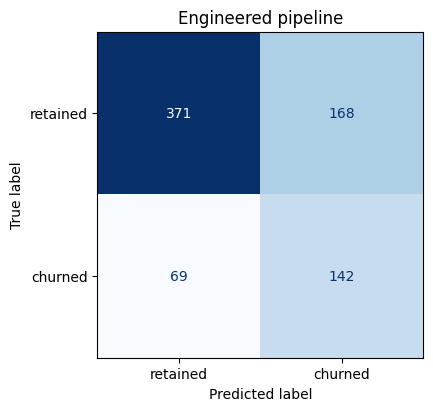

              precision    recall  f1-score   support

    retained       0.84      0.69      0.76       539
     churned       0.46      0.67      0.55       211

    accuracy                           0.68       750
   macro avg       0.65      0.68      0.65       750
weighted avg       0.73      0.68      0.70       750



In [14]:
fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
ConfusionMatrixDisplay.from_estimator(
    engineered_model,
    X_test,
    y_test,
    display_labels=["retained", "churned"],
    cmap="Blues",
    ax=ax,
    colorbar=False,
)
ax.set_title("Engineered pipeline")
ax.grid(False)
plt.show()

print(classification_report(
    y_test,
    engineered_model.predict(X_test),
    target_names=["retained", "churned"],
))


## 10. Inspect Engineered Features

A pipeline does not have to be a black box. After fitting, we can retrieve engineered feature names from the preprocessor and align them with the Logistic Regression coefficients.

Positive coefficients push predictions toward churn. Negative coefficients push predictions toward retention.


In [15]:
def vectorizer_feature_names(vectorizer):
    if hasattr(vectorizer, "get_feature_names_out"):
        return vectorizer.get_feature_names_out()
    return vectorizer.get_feature_names()


def one_hot_feature_names(encoder, columns):
    if hasattr(encoder, "get_feature_names_out"):
        return encoder.get_feature_names_out(columns)
    return encoder.get_feature_names(columns)


def engineered_feature_names(preprocessor):
    try:
        return preprocessor.get_feature_names_out()
    except AttributeError:
        names = []
        for transformer_name, transformer, columns in preprocessor.transformers_:
            if transformer_name == "remainder" and transformer == "drop":
                continue

            if transformer_name == "num":
                column_names = list(columns)
                imputer = transformer.named_steps["simpleimputer"]
                missing_indices = getattr(imputer.indicator_, "features_", [])
                column_names += [f"{columns[index]}_missing" for index in missing_indices]
                names.extend([f"num__{feature}" for feature in column_names])

            elif transformer_name == "log":
                names.extend([f"log__log1p_{feature}" for feature in columns])

            elif transformer_name == "cat":
                encoder = transformer.named_steps["onehotencoder"]
                names.extend([f"cat__{feature}" for feature in one_hot_feature_names(encoder, columns)])

            elif transformer_name == "date":
                extractor = transformer.named_steps["datefeatureextractor"]
                names.extend([f"date__{feature}" for feature in extractor.get_feature_names_out()])

            elif transformer_name == "interaction":
                extractor = transformer.named_steps["customerinteractionfeatures"]
                names.extend([f"interaction__{feature}" for feature in extractor.get_feature_names_out()])

            elif transformer_name == "text":
                names.extend([f"text__{feature}" for feature in vectorizer_feature_names(transformer)])

        return np.array(names, dtype=object)


preprocessor = engineered_model.named_steps["columntransformer"]
classifier = engineered_model.named_steps["logisticregression"]

feature_names = engineered_feature_names(preprocessor)
coefficients = classifier.coef_[0]

coefficient_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "abs_coefficient": np.abs(coefficients),
}).sort_values("coefficient")

print(f"Final engineered feature count: {len(feature_names)}")

display(coefficient_table.head(12))
display(coefficient_table.tail(12))


Final engineered feature count: 59


,feature,coefficient,abs_coefficient
32,text__asked,-0.6461,0.6461
1,num__num_logins_30d,-0.6200,0.6200
41,text__feature,-0.5672,0.5672
10,cat__contract_annual,-0.5255,0.5255
53,text__reported,-0.4096,0.4096
8,cat__plan_plus,-0.4013,0.4013
13,cat__region_north,-0.2862,0.2862
42,text__feedback,-0.2632,0.2632
55,text__shared,-0.2632,0.2632
49,text__positive support,-0.2632,0.2632


,feature,coefficient,abs_coefficient
50,text__pricing,0.4430,0.4430
45,text__mentioned competitor,0.4430,0.4430
38,text__competitor pricing,0.4430,0.4430
44,text__mentioned,0.4430,0.4430
51,text__repeated,0.5203,0.5203
52,text__repeated billing,0.5203,0.5203
54,text__reported repeated,0.5203,0.5203
35,text__billing issue,0.5203,0.5203
43,text__issue,0.5203,0.5203
7,cat__plan_enterprise,0.6035,0.6035


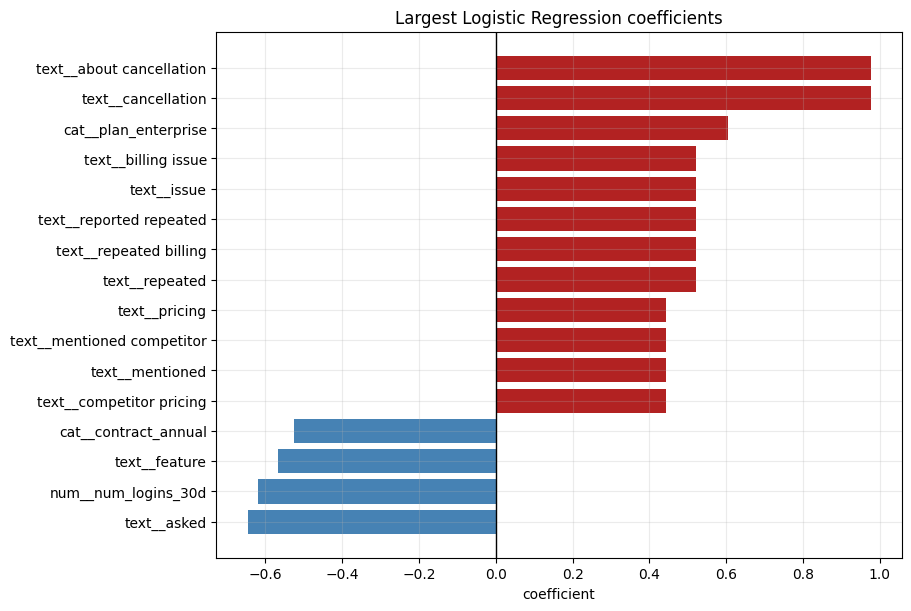

In [16]:
top_coefficients = coefficient_table.sort_values("abs_coefficient", ascending=False).head(16)
plot_data = top_coefficients.sort_values("coefficient")

fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
colors = np.where(plot_data["coefficient"] >= 0, "firebrick", "steelblue")
ax.barh(plot_data["feature"], plot_data["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Largest Logistic Regression coefficients")
ax.set_xlabel("coefficient")
plt.show()


## 11. What to Remember

- Split first, then fit feature engineering steps only on the training data.
- Use `Pipeline` and `ColumnTransformer` to make preprocessing reproducible and leak-resistant.
- Numeric features often need imputation, scaling, and sometimes log or power transforms.
- Categorical features need encoders that can handle unseen categories.
- Dates become useful when converted into durations, recency, calendar, or cyclic features.
- Interaction features help linear models express conditional patterns.
- Text columns can become useful sparse features with TF-IDF.
- Always compare engineered features against a baseline; more features are useful only when they improve validation performance or interpretability.
